In [2]:
%pip install tensorflow tensorflow-hub opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 MB 2.0 MB/s  0:29:28 eta 0:00:010:00:03m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 2.2 MB/s  0:00:05 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 2.1 MB/s  0:00:012.2 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 2.2 MB/s  0:00:00m 2.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 2.1 MB/s  0:00:21 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.3 MB/s  0:00:00m 2.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 2.1 MB/s  0:00:12 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 2.4 MB/s  0:00:00m 2.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24/24 [tensorflow-hub]━ 22/24 [tf-keras]
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 56.1 kB/s  0:00:341.9 kB/s eta 0:00:05:23
  Attempting uninstall: pip
    Found existing installation: pip 25.2
    Uninstalling pip-25.2:
      Successfully uninstalled pip-25.2
Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow as tf
import tensorflow_hub as hub
print("TensorFlow Version:", tf.__version__)
print("Hub Version:", hub.__version__)
print("GPU available:" , tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.21.0
Hub Version: 0.16.1
GPU available: []


In [3]:
import tensorflow as tf
import tensorflow_hub as hub
import cv2
from matplotlib import pyplot as plt
import numpy as np

#Load Model

In [5]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Now your existing code should work:
import tensorflow_hub as hub
model = hub.load('https://www.kaggle.com/models/google/movenet/tensorFlow2/multipose-lightning/1')

In [6]:
model = hub.load('https://www.kaggle.com/models/google/movenet/tensorFlow2/multipose-lightning/1?tfhub-redirect=true')
# downlading the model
movenet = model.signatures['serving_default' ]
# setting variable to the model

In the next cell, we create a cap variable which captures video and 0 depicts the number of the webcam. The while loop cap is open detects if the camera is open. The third statement, frame equal to cap.read(), returns an image from the camera into the variable frame. The next image is equal to frame.copy(), a new variable image where we resize with pad resize. Pad resize means if the image scale is uneven, or doesn't matter which is its original scale, we pad it with zeros to match the given scaling. At last, we define 192 to 256, which also matches the scale of the image.

Next input image, we convert the image into a 32-bit integer. Result, we put the input image into the movement. We define key points with scores, and we give the resulted array. Filter the resulted array in the parts we need. We reshape it to get a numpy array.

Then we define a loop through people which renders different people and draws connections and key points for each by referring to their specific functions. 

In [14]:
cap = cv2.VideoCapture('ab pakka final 2.mp4') # defined a variable to get the video from camera

#check whether the camera si open or not
while cap.isOpened():
    ret, frame = cap.read()
    #returning a variable frame that reads the camera content

    #Resizing the image frame
    img = frame.copy()
    img = tf.image.resize_with_pad(tf.expand_dims(img, axis = 0), 192,256) #resizes the image and if uneven scale pads it with 0s
    input_img = tf.cast(img, dtype=tf.int32) #converts resized image to 32 bit int

    #Making the detections 
    result = movenet(input_img)
    keypoints_with_scores = result['output_0'].numpy()[:,:,:51].reshape((6,17,3))
    

    #rendering people
    loop_through_people(frame , keypoints_with_scores , EDGES , 0.4)
    
    cv2.imshow('Movenet Multipose' , frame)  #renders the image to the screen and passes 2 parameters MovenetMultipose=(name) and frame

    #plan to exit the loop
    if cv2.waitKey(10) & 0xFF==ord('q'):  #1st checks if any key pressed  + 2nd checks that the key presed is Q
        break

cap.release()
cv2.destroyAllWindows()

for i in range(1, 5):
    cv2.waitKey(1)

In [ ]:
result['output_0']. numpy ()[:, :,: 51]

In [8]:
# creating a function to loop through the people and render
def loop_through_people(frame , keypoints_with_scores , edges , confidence_threshold):
    for persons in keypoints_with_scores:
        draw_connections(frame , persons, edges , confidence_threshold)
        draw_keypoints(frame, persons, confidence_threshold)
        

### Drawing keypoints

In [9]:
def draw_keypoints(frame, keypoints, confidence_threshold):
    y, x, c = frame.shape
    shaped = np.squeeze(np.multiply(keypoints, [y,x,1]))
    
    for kp in shaped:
        ky, kx, kp_conf = kp
        if kp_conf > confidence_threshold:
            cv2.circle(frame, (int(kx), int(ky)), 6, (0,255,0), -1)

### Draw edges 

In [10]:
EDGES = {
    (0, 1): 'm',
    (0, 2): 'c',
    (1, 3): 'm',
    (2, 4): 'c',
    (0, 5): 'm',
    (0, 6): 'c',
    (5, 7): 'm',
    (7, 9): 'm',
    (6, 8): 'c',
    (8, 10): 'c',
    (5, 6): 'y',
    (5, 11): 'm',
    (6, 12): 'c',
    (11, 12): 'y',
    (11, 13): 'm',
    (13, 15): 'm',
    (12, 14): 'c',
    (14, 16): 'c'
}

In [11]:
def draw_connections(frame, keypoints, edges, confidence_threshold):
    y, x, c = frame.shape
    shaped = np.squeeze(np.multiply(keypoints, [y,x,1]))
    
    for edge, color in edges.items():
        p1, p2 = edge
        y1, x1, c1 = shaped[p1]
        y2, x2, c2 = shaped[p2]
        
        if (c1 > confidence_threshold) & (c2 > confidence_threshold):      
            cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0,0,255), 4)

### Trying with mp4 file

In [29]:
cap = cv2.VideoCapture('ab pakka final 2.mp4') 


while cap.isOpened():
    ret, frame = cap.read()



    img = frame.copy()
    img = tf.image.resize_with_pad(tf.expand_dims(img, axis = 0), 192,256)
    input_img = tf.cast(img, dtype=tf.int32)

    #Making the detections 
    result = movenet(input_img)
    keypoints_with_scores = result['output_0'].numpy()[:,:,:51].reshape((6,17,3))
    

    #rendering people
    loop_through_people(frame , keypoints_with_scores , EDGES , 0.4)
    
    cv2.imshow('Movenet Multipose' , frame)  

    #plan to exit the loop
    if cv2.waitKey(10) & 0xFF==ord('q'):  #1st checks if any key pressed  + 2nd checks that the key presed is Q
        break

cap.release()
cv2.destroyAllWindows()

for i in range(1, 5):
    cv2.waitKey(1)

In [16]:
frame.shape

(480, 848, 3)

In [24]:
240*1.766

423.84000000000003

In [25]:
423.84 / 32

13.245

In [18]:
848/480

1.7666666666666666

In [26]:
32*13

416

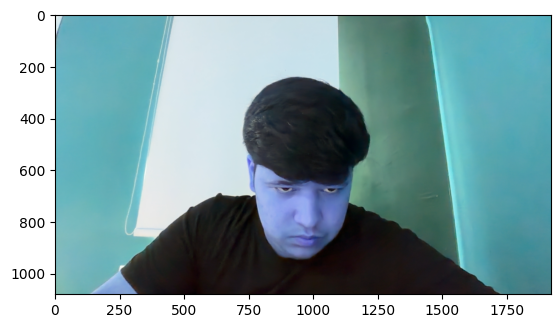

In [41]:
plt.imshow(frame)

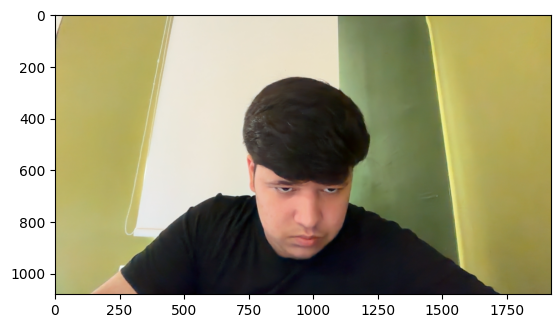

In [42]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))